### Model Performance Comparison

Here's a summary of the performance of all the models trained so far, based on RMSE and R-squared values:

* **Linear Regression:** RMSE = 4.6, R2 = 0.96
* **SARIMA:** RMSE = 53
* **Random Forest:** RMSE = 37, R2 = -1.35
* **XGBoost:** RMSE = 38, R2 = -1.56
* **LSTM:** RMSE = 15, R2 = 0.67

**Note:** While R-squared indicates the proportion of variance explained, RMSE provides a measure of the typical error in the predictions in the original scale of the data. Lower RMSE values indicate better performance.


### Insights and Next Steps

* Based on the RMSE metric, the Linear Regression model performed the best, with the lowest RMSE of 4.6. The LSTM model is the second best with an RMSE of 15
* The Random Forest and XGBoost models had similar RMSE values (around 11), which were higher than Linear Regression and LSTM.
* The SARIMA model had the highest RMSE (53), indicating larger prediction errors compared to the other models.
* Further steps could involve exploring more extensive hyperparameter tuning for all models, trying different feature engineering techniques, or considering other time series models or deep learning approaches that might be better suited for capturing complex patterns in stock price data.
* For real-world stock price prediction, it would be crucial to perform rigorous backtesting and consider factors beyond historical price data.

In [1]:
!pip install yfinance

In [2]:
!pip install tensorflow

In [3]:
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from fastai.tabular.core import add_datepart

In [4]:
# Example: Apple (AAPL)
ticker = yf.Ticker("AAPL")

# Get historical market data
df = ticker.history(period="5y")  # last 1 year
print(df.head())

                                 Open        High         Low       Close  \
Date                                                                        
2021-09-13 00:00:00-04:00  146.920148  147.690684  145.086445  145.866745   
2021-09-14 00:00:00-04:00  146.647073  147.349342  143.291794  144.471985   
2021-09-15 00:00:00-04:00  144.901102  145.759433  142.765037  145.359528   
2021-09-16 00:00:00-04:00  144.784072  145.301017  143.594118  145.125443   
2021-09-17 00:00:00-04:00  145.154757  145.154757  142.170108  142.462723   

                              Volume  Dividends  Stock Splits  
Date                                                           
2021-09-13 00:00:00-04:00  102404300        0.0           0.0  
2021-09-14 00:00:00-04:00  109296300        0.0           0.0  
2021-09-15 00:00:00-04:00   83281300        0.0           0.0  
2021-09-16 00:00:00-04:00   68034100        0.0           0.0  
2021-09-17 00:00:00-04:00  129868800        0.0           0.0  


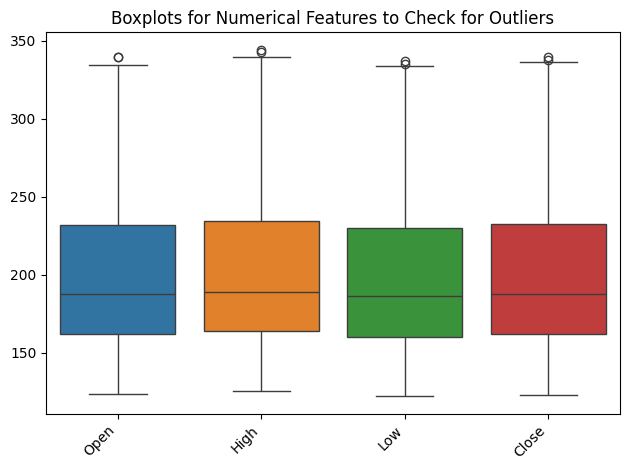

In [5]:
# Check for outliers using boxplots
sns.boxplot(data=df[['Open','High','Low','Close']]) # Plot boxplots for all numerical columns
plt.title('Boxplots for Numerical Features to Check for Outliers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

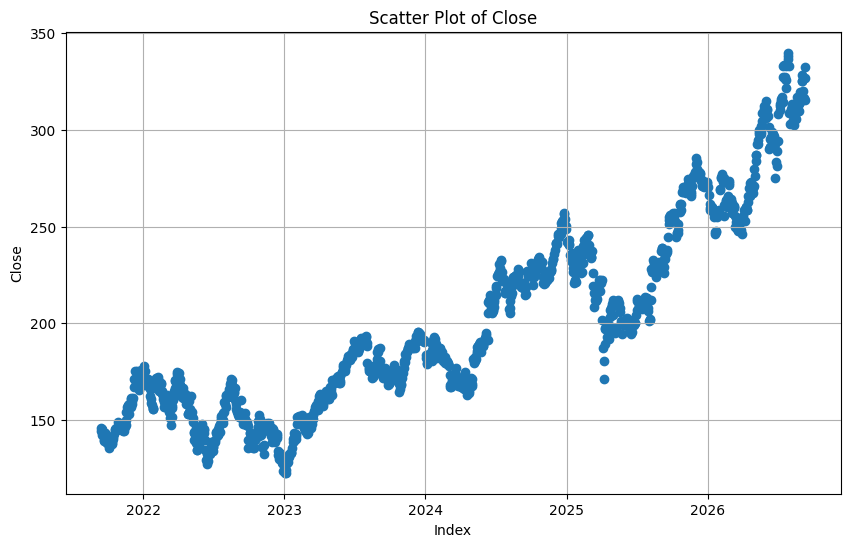

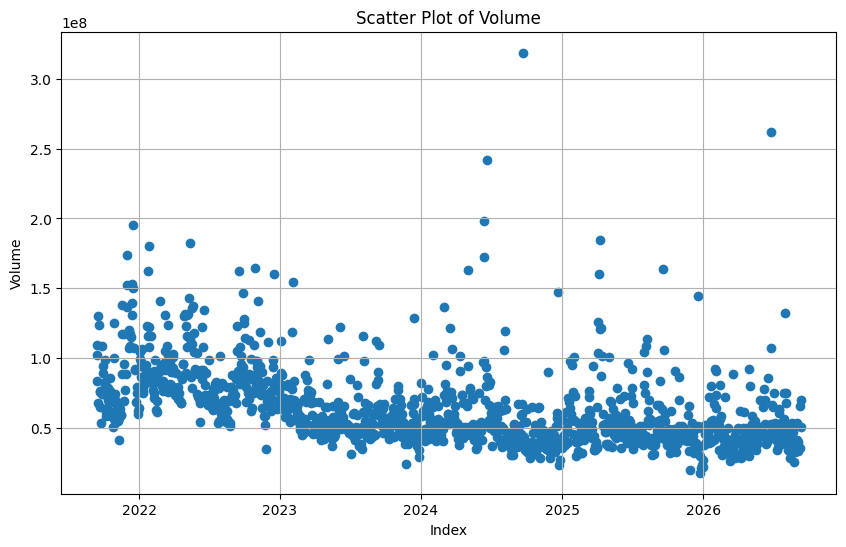

In [6]:
# Generate scatterplots for Close and volume columns
target_cols = ['Close','Volume']

for col in target_cols:
    plt.figure(figsize=(10, 6))
    plt.scatter(df.index, df[col])
    plt.xlabel("Index")
    plt.ylabel(col)
    plt.title(f"Scatter Plot of {col}")
    plt.grid(True)
    plt.show()

<Axes: xlabel='Close', ylabel='Volume'>

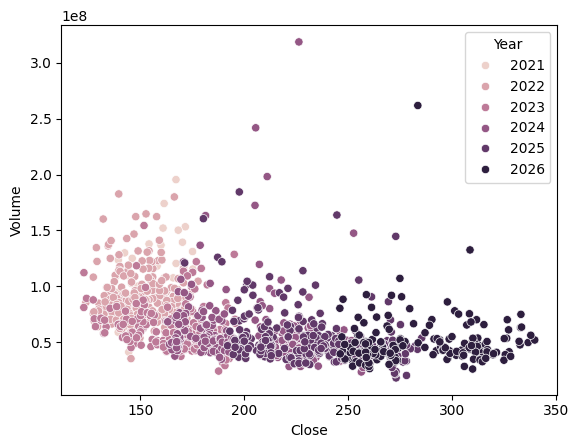

In [7]:
df['Year']=pd.to_datetime(df.index).year
sns.scatterplot(df,x='Close',y='Volume',hue='Year')

In [8]:
df['Date'] = pd.to_datetime(df.index).date
df.index = np.arange(len(df))
display(df.head())

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Year,Date
0,146.920148,147.690684,145.086445,145.866745,102404300,0.0,0.0,2021,2021-09-13
1,146.647073,147.349342,143.291794,144.471985,109296300,0.0,0.0,2021,2021-09-14
2,144.901102,145.759433,142.765037,145.359528,83281300,0.0,0.0,2021,2021-09-15
3,144.784072,145.301017,143.594118,145.125443,68034100,0.0,0.0,2021,2021-09-16
4,145.154757,145.154757,142.170108,142.462723,129868800,0.0,0.0,2021,2021-09-17


In [9]:
df = df.drop(['Dividends', 'Stock Splits'], axis=1)
display(df.head())

,Open,High,Low,Close,Volume,Year,Date
0,146.920148,147.690684,145.086445,145.866745,102404300,2021,2021-09-13
1,146.647073,147.349342,143.291794,144.471985,109296300,2021,2021-09-14
2,144.901102,145.759433,142.765037,145.359528,83281300,2021,2021-09-15
3,144.784072,145.301017,143.594118,145.125443,68034100,2021,2021-09-16
4,145.154757,145.154757,142.170108,142.462723,129868800,2021,2021-09-17


In [10]:
#feature engineering from date using fastAI
add_datepart(df, 'Date', drop=False)
df.drop('Elapsed', axis=1, inplace=True)  #elapsed will be the time stamp

In [11]:
pd.set_option('display.max_columns', None)

In [12]:
df['mon_fri'] = 0
for i in range(0,len(df)):
    if (df['Dayofweek'][i] == 0 or df['Dayofweek'][i] == 4):
        df.loc[i,'mon_fri'] = 1
    else:
        df.loc[i,'mon_fri'] = 0

In [13]:
df.head()

,Open,High,Low,Close,Volume,Year,Date,Month,Week,Day,Dayofweek,Dayofyear,Is_month_end,Is_month_start,Is_quarter_end,Is_quarter_start,Is_year_end,Is_year_start,mon_fri
0,146.920148,147.690684,145.086445,145.866745,102404300,2021,2021-09-13,9,37,13,0,256,False,False,False,False,False,False,1
1,146.647073,147.349342,143.291794,144.471985,109296300,2021,2021-09-14,9,37,14,1,257,False,False,False,False,False,False,0
2,144.901102,145.759433,142.765037,145.359528,83281300,2021,2021-09-15,9,37,15,2,258,False,False,False,False,False,False,0
3,144.784072,145.301017,143.594118,145.125443,68034100,2021,2021-09-16,9,37,16,3,259,False,False,False,False,False,False,0
4,145.154757,145.154757,142.170108,142.462723,129868800,2021,2021-09-17,9,37,17,4,260,False,False,False,False,False,False,1


In [16]:
# Add technical indicators (e.g., Moving Averages) as lagged features
df['SMA_20_Lag1'] = df['Close'].rolling(window=20).mean().shift(1)
df['SMA_50_Lag1'] = df['Close'].rolling(window=50).mean().shift(1)
df['EMA_20_Lag1'] = df['Close'].ewm(span=20, adjust=False).mean().shift(1)
df['EMA_50_Lag1'] = df['Close'].ewm(span=50, adjust=False).mean().shift(1)

# Add RSI as lagged feature
def calculate_rsi(data, window=14):
    diff = data.diff()
    gain = diff.where(diff > 0, 0)
    loss = -diff.where(diff < 0, 0)
    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df['RSI_Lag1'] = calculate_rsi(df['Close']).shift(1)


# Add VWAP as lagged feature
def calculate_vwap(df):
    typical_price = (df['High'] + df['Low'] + df['Close']) / 3
    vwap = (typical_price * df['Volume']).cumsum() / df['Volume'].cumsum()
    return vwap

df['VWAP_Lag1'] = calculate_vwap(df).shift(1)


# Add statistical features (e.g., daily returns, volatility)
df['Daily_Return_Lag1'] = df['Close'].pct_change().shift(1)
df['Volatility_Lag1'] = df['Daily_Return_Lag1'].rolling(window=20).std()

# Add time-series features (e.g., lagged prices)
for i in (1,2,5,10,15,20):
  df[f'Close_Lag{i}'] = df['Close'].shift(i)


# Drop rows with NaN values created by adding new features
df.dropna(inplace=True)

display(df.head())

,Open,High,Low,Close,Volume,Year,Date,Month,Week,Day,Dayofweek,Dayofyear,Is_month_end,Is_month_start,Is_quarter_end,Is_quarter_start,Is_year_end,Is_year_start,mon_fri,SMA_20_Lag1,SMA_50_Lag1,EMA_20_Lag1,EMA_50_Lag1,RSI_Lag1,VWAP_Lag1,Daily_Return_Lag1,Volatility_Lag1,Close_Lag1,Close_Lag2,Close_Lag5,Close_Lag10,Close_Lag15,Close_Lag20
50,157.928182,161.854901,157.263968,157.283508,117467900,2021,2021-11-22,11,47,22,0,326,False,False,False,False,False,False,1,147.489237,143.790363,147.783399,145.590162,78.902749,143.710752,0.016976,0.012351,156.824356,154.206558,146.519211,146.948975,145.291306,144.979172
51,157.381165,158.045393,155.368970,157.664444,96041900,2021,2021-11-23,11,47,23,1,327,False,False,False,False,False,False,0,148.104454,144.018698,148.688172,146.048725,78.276979,144.155619,0.002928,0.012313,157.283508,156.824356,147.495987,147.310394,146.325195,145.642426
52,157.019711,158.377454,155.935468,158.182098,69463600,2021,2021-11-24,11,47,24,2,328,False,False,False,False,False,False,0,148.705555,144.282547,149.543055,146.504243,77.028833,144.458547,0.002422,0.012318,157.664444,157.283508,149.928207,144.487473,147.758972,145.184006
53,155.867136,156.726705,152.731618,153.171173,76959800,2021,2021-11-26,11,47,26,4,330,False,False,False,False,False,False,1,149.355460,144.538999,150.365821,146.962198,79.850798,144.676807,0.003283,0.012204,158.182098,157.664444,154.206558,144.438629,147.242020,148.812378
54,155.671754,157.449528,155.105212,156.521576,88748200,2021,2021-11-29,11,48,29,0,333,False,False,False,False,False,False,1,149.573399,144.699913,150.632997,147.205687,61.841646,144.850371,-0.031678,0.013656,153.171173,158.182098,156.824356,146.509430,147.769470,146.110580


In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Define the features to check for VIF
vif_features = ['SMA_20_Lag1', 'SMA_50_Lag1', 'EMA_20_Lag1', 'EMA_50_Lag1', 'RSI_Lag1', 'VWAP_Lag1']

# Prepare the data by adding a constant (intercept) as required by statsmodels
X_vif = df[vif_features].dropna()
X_vif = add_constant(X_vif)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print("Variance Inflation Factor (VIF) Results:")
display(vif_data)

Variance Inflation Factor (VIF) Results:


,Feature,VIF
0,const,1.000000
1,SMA_20_Lag1,1892.363200
2,SMA_50_Lag1,664.378069
3,EMA_20_Lag1,2378.293045
4,EMA_50_Lag1,1494.756822
5,RSI_Lag1,3.975330
6,VWAP_Lag1,16.711284


In [18]:
# Identify boolean columns
boolean_cols = df.select_dtypes(include='bool').columns

# Convert boolean columns to integers (0s and 1s)
for col in boolean_cols:
    df[col] = df[col].astype(int)

display(df.head(10))

,Open,High,Low,Close,Volume,Year,Date,Month,Week,Day,Dayofweek,Dayofyear,Is_month_end,Is_month_start,Is_quarter_end,Is_quarter_start,Is_year_end,Is_year_start,mon_fri,SMA_20_Lag1,SMA_50_Lag1,EMA_20_Lag1,EMA_50_Lag1,RSI_Lag1,VWAP_Lag1,Daily_Return_Lag1,Volatility_Lag1,Close_Lag1,Close_Lag2,Close_Lag5,Close_Lag10,Close_Lag15,Close_Lag20
50,157.928182,161.854901,157.263968,157.283508,117467900,2021,2021-11-22,11,47,22,0,326,0,0,0,0,0,0,1,147.489237,143.790363,147.783399,145.590162,78.902749,143.710752,0.016976,0.012351,156.824356,154.206558,146.519211,146.948975,145.291306,144.979172
51,157.381165,158.045393,155.368970,157.664444,96041900,2021,2021-11-23,11,47,23,1,327,0,0,0,0,0,0,0,148.104454,144.018698,148.688172,146.048725,78.276979,144.155619,0.002928,0.012313,157.283508,156.824356,147.495987,147.310394,146.325195,145.642426
52,157.019711,158.377454,155.935468,158.182098,69463600,2021,2021-11-24,11,47,24,2,328,0,0,0,0,0,0,0,148.705555,144.282547,149.543055,146.504243,77.028833,144.458547,0.002422,0.012318,157.664444,157.283508,149.928207,144.487473,147.758972,145.184006
53,155.867136,156.726705,152.731618,153.171173,76959800,2021,2021-11-26,11,47,26,4,330,0,0,0,0,0,0,1,149.355460,144.538999,150.365821,146.962198,79.850798,144.676807,0.003283,0.012204,158.182098,157.664444,154.206558,144.438629,147.242020,148.812378
54,155.671754,157.449528,155.105212,156.521576,88748200,2021,2021-11-29,11,48,29,0,333,0,0,0,0,0,0,1,149.573399,144.699913,150.632997,147.205687,61.841646,144.850371,-0.031678,0.013656,153.171173,158.182098,156.824356,146.509430,147.769470,146.110580
55,156.277380,161.679053,156.208997,161.464157,174048100,2021,2021-11-30,11,48,30,1,334,1,0,0,0,0,0,0,150.093949,144.981090,151.193814,147.571016,68.889826,145.087027,0.021874,0.013551,156.521576,153.171173,157.283508,146.519211,146.948975,145.291306
56,163.593547,166.348114,160.712006,160.946442,152052500,2021,2021-12-01,12,48,1,2,335,0,1,0,0,0,0,0,150.902592,145.421983,152.171942,148.115845,73.653355,145.656760,0.031578,0.014730,161.464157,156.521576,157.664444,147.495987,147.310394,146.325195
57,155.056371,160.389661,154.138182,159.959869,136739200,2021,2021-12-02,12,48,2,3,336,0,0,0,0,0,0,0,151.633654,145.842962,153.007609,148.619006,79.801924,146.214022,-0.003206,0.014847,160.946442,161.464157,158.182098,149.928207,144.487473,147.758972
58,160.213862,161.132052,156.013642,158.084442,118023100,2021,2021-12-03,12,48,3,4,337,0,0,0,0,0,0,1,152.243699,146.197001,153.669729,149.063746,77.180971,146.555929,-0.006130,0.014996,159.959869,160.946442,153.171173,154.206558,144.438629,147.242020
59,160.477561,163.984265,160.467798,161.483673,107497000,2021,2021-12-06,12,49,6,0,340,0,0,0,0,0,0,1,152.785820,146.494416,154.090178,149.417499,70.409953,146.841648,-0.011724,0.015324,158.084442,159.959869,156.521576,156.824356,146.509430,147.769470


# Linear regression

In [ ]:
df.head()

**The below heatmap shows that open, high , low , close are highly correlated.
Volume is correlated with high and low**

In [ ]:
plt.figsize=(100,40)
sns.heatmap(df[['Close', 'SMA_20_Lag1', 'SMA_50_Lag1', 'EMA_20_Lag1', 'EMA_50_Lag1' , 'Daily_Return_Lag1', 'Volatility_Lag1', 'Close_Lag5', 'RSI_Lag1', 'VWAP_Lag1']].corr().round(2), annot=True)

Looking at the heatmap, the features that show a high correlation with the 'Close' price are strong candidates for independent variables in our prediction model. These include:

1. **SMA_20, SMA_50, EMA_20, EMA_50:** These moving averages are highly correlated with the 'Close' price, which is expected as they are derived from it.
2. **Close_Lag1,2,5,10,15,20:** Lagged closing prices also show a high correlation, indicating that past prices are good predictors of the current price.
3. **VWAP:** Volume Weighted Average Price is also strongly correlated with the 'Close' price.

Features like 'Daily_Return', 'Volatility', and 'RSI' show lower correlations with 'Close', but they can still be valuable as they might capture different aspects of the price movement not reflected in the moving averages or lagged prices.

## Prepare the data

### Subtask:
Define the features (independent variables) and the target variable ('Close' price).


**feature selection**:
Features were selected to reduce the VIF and faster prediction.



In [19]:
features = ['Year', 'Month', 'Week', 'Day', 'Dayofweek', 'Dayofyear', 'SMA_20_Lag1', 'EMA_20_Lag1', 'RSI_Lag1', 'VWAP_Lag1', 'Close_Lag1','Close_Lag2','Close_Lag5','Close_Lag10','Close_Lag15','Close_Lag20']
target = 'Close'
X = df[features]
y = df[target]

**Reasoning**:
Divide the data into training and testing sets for model evaluation.



## Split the data sequentially

### Subtask:
Divide the dataset into training and testing sets sequentially to preserve the time series order.


**Reasoning**:
Divide the data into training and testing sets sequentially to preserve the time series order.



In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

## Build the model

### Subtask:
Create a multiple linear regression model using a library like scikit-learn.


**Reasoning**:
Create a multiple linear regression model using scikit-learn.



In [21]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

## Train the model

### Subtask:
Fit the model to the training data.


**Reasoning**:
Fit the linear regression model to the training data.



In [22]:
model.fit(X_train, y_train)

LinearRegression()

## Make predictions

### Subtask:
Use the trained model to predict the 'Close' price on the test data.


**Reasoning**:
Use the trained linear regression model to predict the 'Close' prices on the test features.



In [23]:
y_pred = model.predict(X_test)

## Evaluate the model

### Subtask:
Assess the performance of the model using appropriate metrics.


**Reasoning**:
Calculate and print the Mean Squared Error and R-squared score to assess the model's performance.



In [24]:
from sklearn.metrics import root_mean_squared_error, r2_score

rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (MSE): {rmse}")
print(f"R-squared (R2): {r2}")

Root Mean Squared Error (MSE): 4.6732009091298625
R-squared (R2): 0.963883466005252


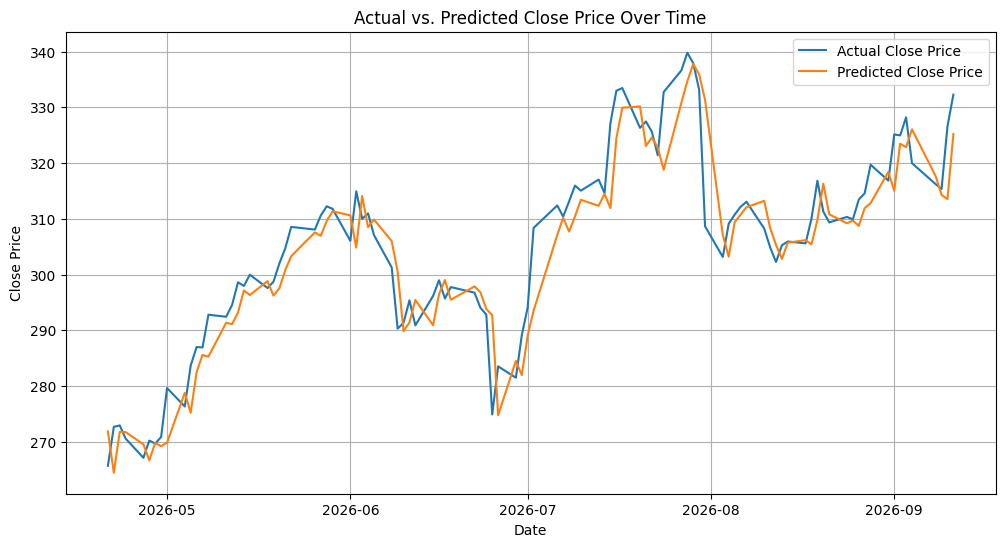

In [25]:
#to check the last n days prices v/s pred
days=-100

plt.figure(figsize=(12, 6))
plt.plot(pd.to_datetime(df.loc[X_test[days:].index, 'Date']), y_test[days:], label='Actual Close Price')
plt.plot(pd.to_datetime(df.loc[X_test[days:].index, 'Date']), y_pred[days:], label='Predicted Close Price')
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("Actual vs. Predicted Close Price Over Time")
plt.legend()
plt.grid(True)
plt.show()

## Summary:

### Data Analysis Key Findings

* The data was sequentially split into training (80%) and testing (20%) sets to preserve the time series order.
* A multiple linear regression model was successfully built and trained on the training data using date-related features, lagged technical indicators (SMA\_20\_Lag1, EMA\_20\_Lag1, VWAP\_Lag1).
* The model's predictions on the test set resulted in Root Mean Squared Error (MSE) of approximately 4.6.
* The R-squared (R2) value for the model's performance on the test set is approximately 0.96, suggesting that the model explains a significant portion of the variance in the 'Close' price.

### Insights or Next Steps

* The relatively low RMSE and high R-squared value indicate that the linear regression model with the selected features performs reasonably well in predicting the 'Close' price.
* The visualization shows that the Linear Regression model with the updated features tracks the actual 'Close' prices much better than before, capturing the overall trend and many of the fluctuations.
* Further steps could involve exploring other machine learning models, hyperparameter tuning, or incorporating additional relevant features to potentially improve prediction accuracy further.

# SARIMA
Build a SARIMA model to predict the "Close" column of the dataset.

## Prepare data for sarima

### Subtask:
Ensure the data is in a suitable format for time series analysis, likely requiring the 'Date' column as the index and focusing on the 'Close' price.


**Reasoning**:
Create a new DataFrame with 'Date' as the index and 'Close' as the only column for SARIMA modeling.



In [ ]:
df_sarima = df[['Year', 'Month', 'Week', 'Day', 'Dayofweek', 'Dayofyear', 'SMA_20_Lag1', 'EMA_20_Lag1', 'RSI_Lag1', 'VWAP_Lag1', 'Close_Lag5','Close']].copy()
display(df_sarima.head())

,Year,Month,Week,Day,Dayofweek,Dayofyear,SMA_20_Lag1,EMA_20_Lag1,RSI_Lag1,VWAP_Lag1,Close_Lag5,Close
100,2022,1,5,31,0,31,166.056065,163.905450,47.172827,165.108057,157.869568,170.724152
101,2022,2,5,1,1,32,165.919801,164.554850,53.502836,165.191195,156.072250,170.558121
102,2022,2,5,2,2,33,165.558387,165.126590,49.313898,165.263366,155.984329,171.759537
103,2022,2,5,3,3,34,165.369865,165.758299,50.442394,165.348294,155.525253,168.887802
104,2022,2,5,4,4,35,165.271207,166.056347,51.025173,165.415941,166.377457,168.604172


**Reasoning**:
Generate and display ACF and PACF plots for the 'Close' price series to analyze its stationarity and identify potential SARIMA parameters.



## Check for stationarity using dickey-fuller test

### Subtask:
Perform the Augmented Dickey-Fuller test on the 'Close' price series to determine if it is stationary.


**Reasoning**:
Perform the Augmented Dickey-Fuller test on the 'Close' price series to check for stationarity.



In [ ]:
from statsmodels.tsa.stattools import adfuller

# Perform the Augmented Dickey-Fuller test
result = adfuller(df_sarima['Close'])

# Print the results
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

# Interpret the p-value
if result[1] <= 0.05:
    print("The time series is likely stationary.")
else:
    print("The time series is likely non-stationary.")

ADF Statistic: -0.367654
p-value: 0.915361
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568
The time series is likely non-stationary.


**Reasoning**:
The Augmented Dickey-Fuller test indicates that the time series is non-stationary (p-value > 0.05). To make it stationary, we need to difference the series.



In [ ]:
# Difference the series to make it stationary
df_sarima['Close_diff'] = df_sarima['Close'].diff().dropna()

# Perform the Augmented Dickey-Fuller test on the differenced series
result_diff = adfuller(df_sarima['Close_diff'].dropna())

# Print the results for the differenced series
print('ADF Statistic (Differenced): %f' % result_diff[0])
print('p-value (Differenced): %f' % result_diff[1])
print('Critical Values (Differenced):')
for key, value in result_diff[4].items():
    print('\t%s: %.3f' % (key, value))

# Interpret the p-value for the differenced series
if result_diff[1] <= 0.05:
    print("The differenced time series is likely stationary.")
else:
    print("The differenced time series is likely non-stationary.")

ADF Statistic (Differenced): -32.446491
p-value (Differenced): 0.000000
Critical Values (Differenced):
	1%: -3.436
	5%: -2.864
	10%: -2.568
The differenced time series is likely stationary.


**This Means that 1 order differencing shall work to make it stationary. Hence d=1 in SARIMA**



## Determine sarima order

### Subtask:
Analyze the time series data (e.g., using ACF and PACF plots) to determine appropriate values for the SARIMA parameters (p, d, q, P, D, Q, s).


**Reasoning**:
Generate and display ACF and PACF plots for the differenced 'Close' price series to analyze its stationarity and identify potential SARIMA parameters.



<Figure size 1200x600 with 0 Axes>

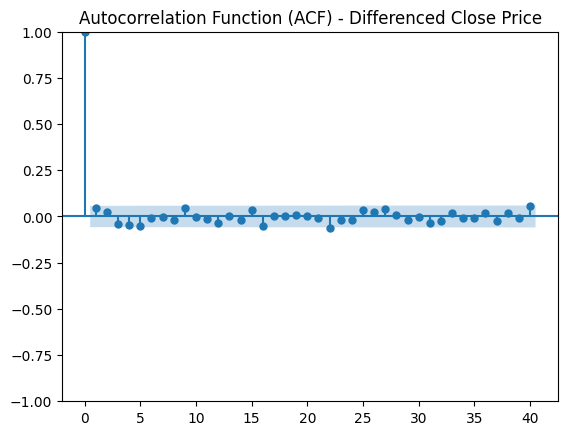

<Figure size 1200x600 with 0 Axes>

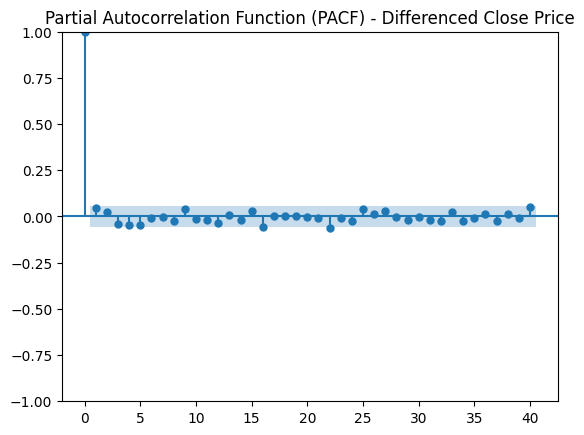

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF of differenced series
plt.figure(figsize=(12, 6))
plot_acf(df_sarima['Close_diff'].dropna(), lags=40, title='Autocorrelation Function (ACF) - Differenced Close Price')
plt.show()

# Plot PACF of differenced series
plt.figure(figsize=(12, 6))
plot_pacf(df_sarima['Close_diff'].dropna(), lags=40, title='Partial Autocorrelation Function (PACF) - Differenced Close Price')
plt.show()

## Build and train sarima model

### Subtask:
Create and fit the SARIMA model to the training data using the determined order.


**Reasoning**:
Create and fit the SARIMA model to the training data using the determined order (1, 1, 1) and seasonal order (0, 0, 0, 0).



In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Split the data into training and testing sets (80/20 split for time series)
train_size = int(len(df_sarima) * 0.8)
train_data, test_data = df_sarima[0:train_size], df_sarima[train_size:]

# Define the SARIMA model order (p, d, q) and seasonal order (P, D, Q, s)
# Based on the previous ACF and PACF analysis, (1, 1, 1) for non-seasonal
# and (0, 0, 0, 0) for seasonal seems a reasonable starting point.
order = (1, 1, 1)
seasonal_order = (0, 0, 0, 0)

# Create and fit the SARIMA model, SARIMA model auto differences and auto inverts, hence no need to pass close_diff, rather pass close
sarima_model = SARIMAX(train_data['Close'],
                       order=order,
                       exog=train_data[['Year', 'Month', 'Week', 'Day', 'Dayofweek', 'Dayofyear','SMA_20_Lag1', 'EMA_20_Lag1', 'VWAP_Lag1', 'Close_Lag5']],
                       seasonal_order=seasonal_order,
                       enforce_stationarity=False,
                       enforce_invertibility=False)

sarima_results = sarima_model.fit()

# Print the model summary
print(sarima_results.summary())

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  924
Model:               SARIMAX(1, 1, 1)   Log Likelihood               -2390.200
Date:                Tue, 08 Sep 2026   AIC                           4806.400
Time:                        19:49:05   BIC                           4869.131
Sample:                             0   HQIC                          4830.337
                                - 924                                         
Covariance Type:                  opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Year           19.8804     35.433      0.561      0.575     -49.567      89.328
Month          -6.1863     24.390     -0.254      0.800     -53.989      41.617
Week            0.0298      0.115      0.259    

/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## Make predictions

### Subtask:
Use the trained SARIMA model to forecast the 'Close' price on the test data.


In [ ]:
sarima_predictions = sarima_results.predict(start=len(train_data), end=len(df_sarima) - 1,exog=test_data[['Year', 'Month', 'Week', 'Day', 'Dayofweek', 'Dayofyear','SMA_20_Lag1', 'EMA_20_Lag1', 'VWAP_Lag1', 'Close_Lag5']])

#
display(sarima_predictions.head())

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


,predicted_mean
924,255.561976
925,255.594691
926,255.811634
927,256.248163
928,257.015292


## Evaluate the model

### Subtask:
Assess the performance of the SARIMA model using appropriate time series evaluation metrics.


**Reasoning**:
Calculate and print the Root Mean Squared Error (RMSE) between the actual and predicted 'Close' prices to evaluate the SARIMA model's performance.



In [ ]:
from sklearn.metrics import mean_squared_error

rmse_sarima = np.sqrt(mean_squared_error(test_data['Close'], sarima_predictions))

print(f"Root Mean Squared Error (RMSE) for SARIMA: {rmse_sarima}")

Root Mean Squared Error (RMSE) for SARIMA: 53.0474919681671


In [ ]:
display(sarima_predictions.size)
display(test_data['Close_diff'].size)

#replacing the wrong index of sarima_predicitons got during training from test_data's date index
sarima_predictions.index = test_data.index

display(sarima_predictions.head())

231

231

,predicted_mean
1024,255.561976
1025,255.594691
1026,255.811634
1027,256.248163
1028,257.015292


## Visualize results

### Subtask:
Plot the actual 'Close' prices against the predicted values from the SARIMA model.


**Reasoning**:
Plot the actual and predicted 'Close' prices to visually assess the SARIMA model's performance.



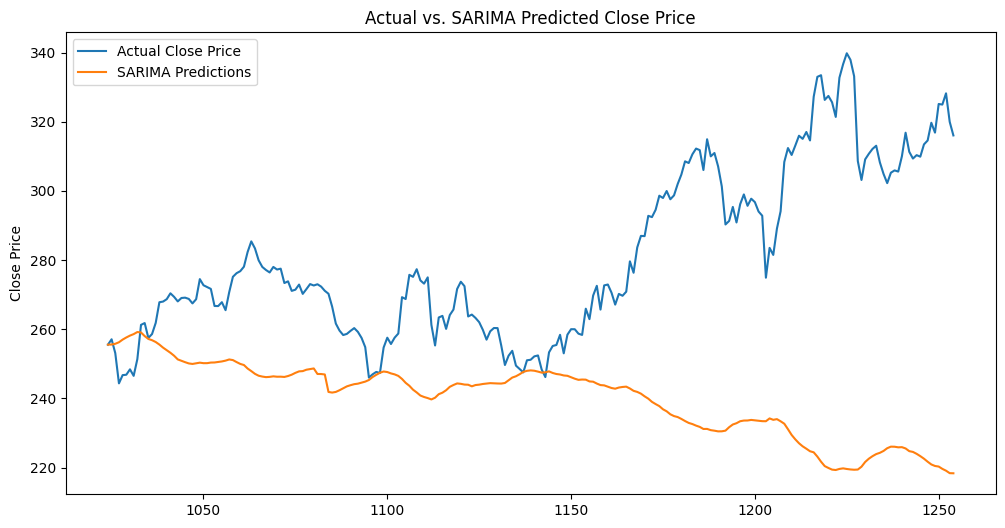

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(test_data.index, test_data['Close'], label='Actual Close Price')
plt.plot(sarima_predictions.index, sarima_predictions, label='SARIMA Predictions')
plt.title("Actual vs. SARIMA Predicted Close Price")
plt.ylabel("Close Price")
plt.legend()
plt.show()


### Data Analysis Key Findings

* The Augmented Dickey-Fuller test initially indicated that the 'Close' price series was non-stationary.
* Differencing the series once made it stationary, suggesting that an integrated (I) component of order 1 (d=1) is appropriate for the SARIMA model.
* Analysis of the ACF and PACF plots of the differenced series helped in determining the potential non-seasonal orders (p, q).
* A SARIMA model with order (1, 1, 1) and seasonal order (0, 0, 0, 0) was built and trained on the data.

### Model Performance

* The SARIMA model's predictions on the test set resulted in a Root Mean Squared Error (RMSE) of approximately 53.
* The visualization shows that the SARIMA model, with the chosen order, struggles to capture the fluctuations and trends in the actual 'Close' prices, essentially predicting a relatively flat line. This suggests that the chosen SARIMA order might not be optimal for this dataset, or that a simple SARIMA model without considering external factors might not be sufficient for accurately predicting stock prices.

# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df_random_forest=df.copy()

In [ ]:
df_random_forest.head()

,Open,High,Low,Close,Volume,Year,Date,Month,Week,Day,Dayofweek,Dayofyear,Is_month_end,Is_month_start,Is_quarter_end,Is_quarter_start,Is_year_end,Is_year_start,mon_fri,SMA_20_Lag1,SMA_50_Lag1,EMA_20_Lag1,EMA_50_Lag1,RSI_Lag1,VWAP_Lag1,Daily_Return_Lag1,Volatility_Lag1,Close_Lag1,Close_Lag5
100,166.211366,170.939048,165.576440,170.724152,115541600,2022,2022-01-31,1,5,31,0,31,1,0,0,0,0,0,1,166.056065,165.649525,163.905450,163.666068,47.172827,165.108057,0.069778,0.021125,166.377457,157.869568
101,169.972038,170.782779,168.311490,170.558121,86213900,2022,2022-02-01,2,5,1,1,32,0,1,0,0,0,0,0,165.919801,166.065443,164.554850,163.942856,53.502836,165.191195,0.026126,0.022036,170.724152,156.072250
102,170.694834,171.798617,169.307788,171.759537,84914300,2022,2022-02-02,2,5,2,2,33,0,0,0,0,0,0,0,165.558387,166.392474,165.126590,164.202278,49.313898,165.263366,-0.000973,0.021200,170.558121,155.984329
103,170.431140,172.150308,168.125903,168.887802,89418100,2022,2022-02-03,2,5,3,3,34,0,0,0,0,0,0,0,165.369865,166.691177,165.758299,164.498641,50.442394,165.348294,0.007044,0.021128,171.759537,155.525253
104,167.909757,170.276625,166.931718,168.604172,82465400,2022,2022-02-04,2,5,4,4,35,0,0,0,0,0,0,1,165.271207,166.923264,166.056347,164.670765,51.025173,165.415941,-0.016720,0.020604,168.887802,166.377457


In [ ]:
from sklearn.model_selection import train_test_split

features = ['Year', 'Month', 'Week', 'Day', 'Dayofweek', 'Dayofyear', 'SMA_20_Lag1', 'SMA_50_Lag1', 'EMA_20_Lag1', 'EMA_50_Lag1', 'RSI_Lag1', 'VWAP_Lag1', 'Close_Lag1', 'Close_Lag5','Is_month_end',	'Is_month_start',	'Is_quarter_end', 'Is_quarter_start', 'Is_year_end',	'Is_year_start']
target = 'Close'
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for n_estimators
param_grid = {'n_estimators': [50, 100, 150, 200, 250]} # You can adjust these values

# Create a GridSearchCV object
grid_search = GridSearchCV(estimator=RandomForestRegressor(random_state=42),
                           param_grid=param_grid,
                           cv=5, # 5-fold cross-validation
                           scoring='neg_mean_squared_error', # Use negative MSE for scoring
                           n_jobs=-1) # Use all available cores

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and the best score
best_n_estimators = grid_search.best_params_['n_estimators']
best_rmse = np.sqrt(-grid_search.best_score_)

print(f"Best n_estimators found: {best_n_estimators}")
print(f"RMSE with best n_estimators: {best_rmse}")

Best n_estimators found: 250
RMSE with best n_estimators: 6.854732304890276


In [ ]:
# Build and train the Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=250, random_state=42) # You can adjust n_estimators

rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=250, random_state=42)

In [ ]:
# Make predictions on the test set
rf_predictions = rf_model.predict(X_test)

# Evaluate the model
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_predictions))
r2_rf = r2_score(y_test, rf_predictions)

print(f"Root Mean Squared Error (RMSE) for Random Forest: {rmse_rf}")
print(f"R-squared (R2) for Random Forest: {r2_rf}")

Root Mean Squared Error (RMSE) for Random Forest: 37.09212771964846
R-squared (R2) for Random Forest: -1.3519883057217612


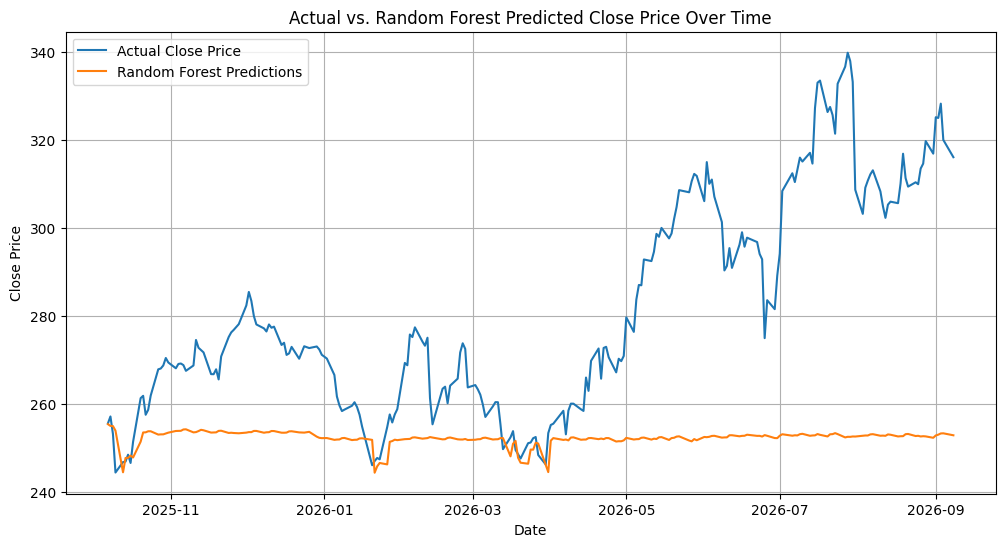

In [ ]:
# Visualize the results (optional)
plt.figure(figsize=(12, 6))
plt.plot(pd.to_datetime(df_random_forest.loc[X_test.index, 'Date']), y_test, label='Actual Close Price')
plt.plot(pd.to_datetime(df_random_forest.loc[X_test.index, 'Date']), rf_predictions, label='Random Forest Predictions')
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("Actual vs. Random Forest Predicted Close Price Over Time")
plt.legend()
plt.grid(True)
plt.show()

## Random Forest Model Summary:

### Model Performance

* The Random Forest model's predictions on the test set resulted in a Root Mean Squared Error (RMSE) of approximately 37.
* The R-squared (R2) value for the Random Forest model on the test set is approximately -1.351.
* The visualization shows that the Random Forest model captures some of the trend and some fluctuations in the actual 'Close' prices, performing better than the SARIMA model but not as closely tracking the rapid changes.

* The Random Forest model showed better performance than SARIMA but did not outperform the simpler Linear Regression model in this case.


# XGBoost

Build an XGBoost model to predict the 'Close' stock price.

## Prepare the data for xgboost

### Subtask:
Define the features (independent variables) and the target variable ('Close' price) and create the corresponding dataframes and series.


**Reasoning**:
Define the features and target variables and create the corresponding dataframes and series for the XGBoost model.



In [ ]:
features = ['Year', 'Month', 'Week', 'Day', 'Dayofweek', 'Dayofyear', 'SMA_20_Lag1', 'SMA_50_Lag1', 'EMA_20_Lag1', 'EMA_50_Lag1', 'RSI_Lag1', 'VWAP_Lag1', 'Close_Lag1', 'Close_Lag5']
target = 'Close'
X = df[features]
y = df[target]

## Split the data sequentially

### Subtask:
Split the data sequentially

#### Instructions
Divide the dataset into training and testing sets sequentially to preserve the time series order.


**Reasoning**:
Divide the data into training and testing sets sequentially to preserve the time series order.



In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

## Build the xgboost model

### Subtask:
Create an XGBoost Regressor model.


**Reasoning**:
Create an XGBoost Regressor model.



In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for hyperparameter tuning
# These are example parameters, you can expand this grid
param_grid = {
    'n_estimators': [50, 100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'max_depth': [3, 5, 7]
}

# Create a GridSearchCV object
grid_search = GridSearchCV(estimator=XGBRegressor(objective='reg:squarederror', random_state=42),
                           param_grid=param_grid,
                           cv=5,  # 5-fold cross-validation
                           scoring='neg_mean_squared_error',  # Use negative MSE for scoring
                           n_jobs=-1)  # Use all available cores

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and the best score
best_params = grid_search.best_params_
best_rmse = np.sqrt(-grid_search.best_score_)

print(f"Best parameters found: {best_params}")
print(f"RMSE with best parameters: {best_rmse}")

# Build the XGBoost Regressor model with the best parameters
xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42, **best_params)

Best parameters found: {'learning_rate': 0.3, 'max_depth': 5, 'n_estimators': 50}
RMSE with best parameters: 6.800602823831384


## Train the xgboost model

### Subtask:
Fit the XGBoost model to the training data.


**Reasoning**:
Fit the XGBoost model to the training data.



In [ ]:
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.3, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=50,
             n_jobs=None, num_parallel_tree=None, ...)

## Make predictions with xgboost

### Subtask:
Use the trained XGBoost model to predict the 'Close' price on the test data.


**Reasoning**:
Use the trained XGBoost regressor model to predict the 'Close' price on the test features.



In [ ]:
xgb_predictions = xgb_model.predict(X_test)
display(xgb_predictions[:5])

array([256.4298 , 255.9542 , 254.64496, 254.30006, 242.06412],
      dtype=float32)

## Evaluate the xgboost model

### Subtask:
Assess the performance of the XGBoost model using appropriate metrics like RMSE and R-squared.


**Reasoning**:
Calculate and print the Root Mean Squared Error (RMSE) and R-squared score to assess the XGBoost model's performance.



In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_predictions))
r2_xgb = r2_score(y_test, xgb_predictions)

print(f"Root Mean Squared Error (RMSE) for XGBoost: {rmse_xgb}")
print(f"R-squared (R2) for XGBoost: {r2_xgb}")

Root Mean Squared Error (RMSE) for XGBoost: 38.770662061391
R-squared (R2) for XGBoost: -1.5696744091088095


## Visualize xgboost results

### Subtask:
Plot the actual 'Close' prices against the predicted values from the XGBoost model.


**Reasoning**:
Plot the actual and predicted 'Close' prices to visually assess the XGBoost model's performance.



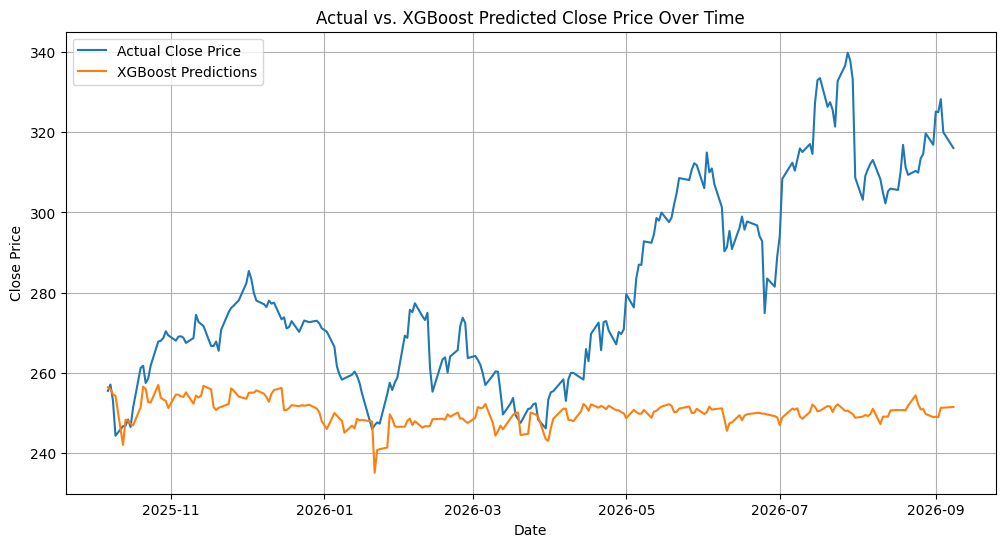

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(pd.to_datetime(df.loc[X_test.index, 'Date']), y_test, label='Actual Close Price')
plt.plot(pd.to_datetime(df.loc[X_test.index, 'Date']), xgb_predictions, label='XGBoost Predictions')
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("Actual vs. XGBoost Predicted Close Price Over Time")
plt.legend()
plt.grid(True)
plt.show()

## Summary:

### Data Analysis Key Findings

* An XGBoost Regressor model was successfully built and trained to predict the 'Close' stock price using the specified features.
* The data was split sequentially into training and testing sets (80% train, 20% test) to preserve the time series order.
* Hyperparameter tuning using GridSearchCV was performed to find the optimal `n_estimators`, `learning_rate`, and `max_depth` for the XGBoost model. The best parameters found were `{'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 50}`.
* The model achieved a Root Mean Squared Error (RMSE) of approximately 38 on the test set.

* A visualization comparing the actual and predicted 'Close' prices showed that the XGBoost predictions follow the general trend of the actual values but do not perfectly capture all the fluctuations.

### Insights or Next Steps

* The XGBoost model, even with hyperparameter tuning, performed similarly to the Random Forest model and did not outperform the Linear Regression model in terms of RMSE and R-squared on this specific dataset and feature set.
* Further steps could involve exploring more extensive hyperparameter tuning, trying different feature engineering techniques, or considering other time series models or deep learning approaches that might be better suited for capturing complex patterns in stock price data.

# LSTM
Build LSTM model to predict the close stock price, using independent variables in df ['Year', 'Month', 'Week', 'Day', 'Dayofweek', 'Dayofyear', 'SMA_20_Lag1', 'SMA_50_Lag1', 'EMA_20_Lag1', 'EMA_50_Lag1', 'RSI_Lag1', 'VWAP_Lag1', 'Close_Lag1', 'Close_Lag5'] and summarize the results of all the models trained so far.

## Prepare data for lstm

### Subtask:
Scale the data and create sequences for LSTM input.


**Reasoning**:
Select features including 'Close', scale the data, create sequences for LSTM input, and split into training and testing sets.



In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# --------------------------------------------------
# 1. Select features
# --------------------------------------------------

lstm_features = [
    'Close',
    'Year',
    'Month',
    'Week',
    'Day',
    'Dayofweek',
    'Dayofyear',
    'mon_fri',
    'SMA_20_Lag1',
    'EMA_20_Lag1',
    'Close_Lag5'
]

df_lstm = df[lstm_features].copy()


# --------------------------------------------------
# 2. Train/Test split on the ORIGINAL time series
# --------------------------------------------------

split_index = int(len(df_lstm) * 0.8)

train_data = df_lstm.iloc[:split_index]
test_data = df_lstm.iloc[split_index:]


# --------------------------------------------------
# 3. Create separate scalers
# --------------------------------------------------

X_scaler = MinMaxScaler(feature_range=(0, 1))
y_scaler = MinMaxScaler(feature_range=(0, 1))


# Fit X scaler ONLY on training data
X_scaler.fit(train_data)

# Fit y scaler ONLY on training Close prices
y_scaler.fit(train_data[['Close']])


# --------------------------------------------------
# 4. Transform data
# --------------------------------------------------

train_scaled = X_scaler.transform(train_data)
test_scaled = X_scaler.transform(test_data)

# For y, scale Close separately
y_train_scaled = y_scaler.transform(
    train_data[['Close']]
).flatten()

y_test_scaled = y_scaler.transform(
    test_data[['Close']]
).flatten()


# --------------------------------------------------
# 5. Create sequences
# --------------------------------------------------

sequence_length = 60

def create_sequences(X_data, y_data, sequence_length):
    X_sequences = []
    y_sequences = []

    for i in range(len(X_data) - sequence_length):
        X_sequences.append(
            X_data[i:i + sequence_length]
        )

        y_sequences.append(
            y_data[i + sequence_length]
        )

    return np.array(X_sequences), np.array(y_sequences)


X_train_lstm, y_train_lstm = create_sequences(
    train_scaled,
    y_train_scaled,
    sequence_length
)


X_test_lstm, y_test_lstm = create_sequences(
    test_scaled,
    y_test_scaled,
    sequence_length
)


# --------------------------------------------------
# 6. Check shapes
# --------------------------------------------------

print(f"Shape of X_train_lstm: {X_train_lstm.shape}")
print(f"Shape of y_train_lstm: {y_train_lstm.shape}")
print(f"Shape of X_test_lstm: {X_test_lstm.shape}")
print(f"Shape of y_test_lstm: {y_test_lstm.shape}")

Shape of X_train_lstm: (864, 60, 11)
Shape of y_train_lstm: (864,)
Shape of X_test_lstm: (171, 60, 11)
Shape of y_test_lstm: (171,)


## Build lstm model

### Subtask:
Define the architecture of the LSTM model.


**Reasoning**:
Define the architecture of the LSTM model using Sequential, LSTM, and Dense layers, and print the model summary.



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# 2. Create a Sequential model
lstm_model = Sequential()

# 3. Add an LSTM layer
# The input shape is (sequence_length, number_of_features)
lstm_model.add(LSTM(units=50, return_sequences=False, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))

# 4. Add a Dense layer
lstm_model.add(Dense(units=1))

# 5. Print the model summary
lstm_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        12,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,451 (48.64 KB)

 Trainable params: 12,451 (48.64 KB)

 Non-trainable params: 0 (0.00 B)

## Train lstm model

### Subtask:
Compile and train the LSTM model.


**Reasoning**:
Compile and train the LSTM model using the specified optimizer, loss function, epochs, batch size, and validation split.



In [ ]:
# 1. Compile the lstm_model
lstm_model.compile(optimizer='adam', loss='mean_squared_error')

# 2. Train the lstm_model
history = lstm_model.fit(X_train_lstm, y_train_lstm,
                         epochs=50,
                         batch_size=32,
                         validation_split=0.2,
                         verbose=1)

# Print the training history
print(history.history)

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0622 - val_loss: 0.0093
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0063 - val_loss: 0.0086
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0036 - val_loss: 0.0099
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0033 - val_loss: 0.0093
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0030 - val_loss: 0.0094
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0028 - val_loss: 0.0084
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0026 - val_loss: 0.0089
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0025 - val_loss: 0.0079
Epoch 9/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0024 - val_loss: 0.0075
Epoch 10/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0023 - val_loss: 0.0075
Epoch 11/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0023 - val_loss: 0.0074
Epoch 12/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0

## Make predictions with lstm

### Subtask:
Use the trained LSTM model to predict the 'Close' price on the test data.


**Reasoning**:
Use the trained LSTM model to make predictions on the test data and inverse transform both the predictions and the actual test values.



In [ ]:
import numpy as np
import tensorflow

try:
    lstm_model = tensorflow.keras.models.load_model('lstm_stock_price_model.keras')
except Exception as e:
  print(f"Error loading the model: {e}")

# Use the trained lstm_model to make predictions on the X_test_lstm dataset
lstm_scaled_predictions = lstm_model.predict(X_test_lstm)

# Inverse transform the predictions back to the original scale
# Use y_scaler for inverse transformation of the 'Close' price predictions
lstm_predictions = y_scaler.inverse_transform(lstm_scaled_predictions)

# Inverse transform the actual y_test_lstm values back to the original scale
y_test_actual_unscaled = y_scaler.inverse_transform(y_test_lstm.reshape(-1, 1))

# Display the first few values of lstm_predictions and y_test_actual_unscaled
print("LSTM Predictions (unscaled):")
display(lstm_predictions[:5])
print("\nActual Test Close Prices (unscaled):")
display(y_test_actual_unscaled[:5])

Error loading the model: File not found: filepath=lstm_stock_price_model.keras. Please ensure the file is an accessible `.keras` zip file.
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
LSTM Predictions (unscaled):


array([[264.5646 ],
       [259.9466 ],
       [258.00452],
       [253.23979],
       [250.40569]], dtype=float32)


Actual Test Close Prices (unscaled):


array([[270.27435303],
       [266.5345459 ],
       [261.64779663],
       [259.62332153],
       [258.33682251]])

**Reasoning**:
Calculate and print the Root Mean Squared Error (RMSE) and R-squared score to assess the LSTM model's performance.



In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Calculate RMSE
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual_unscaled, lstm_predictions))

# Calculate R-squared
r2_lstm = r2_score(y_test_actual_unscaled, lstm_predictions)

print(f"Root Mean Squared Error (RMSE) for LSTM: {rmse_lstm}")
print(f"R-squared (R2) for LSTM: {r2_lstm}")

Root Mean Squared Error (RMSE) for LSTM: 15.103822230550998
R-squared (R2) for LSTM: 0.6670758567366125


**Reasoning**:
Plot the actual and predicted 'Close' prices to visually assess the LSTM model's performance.



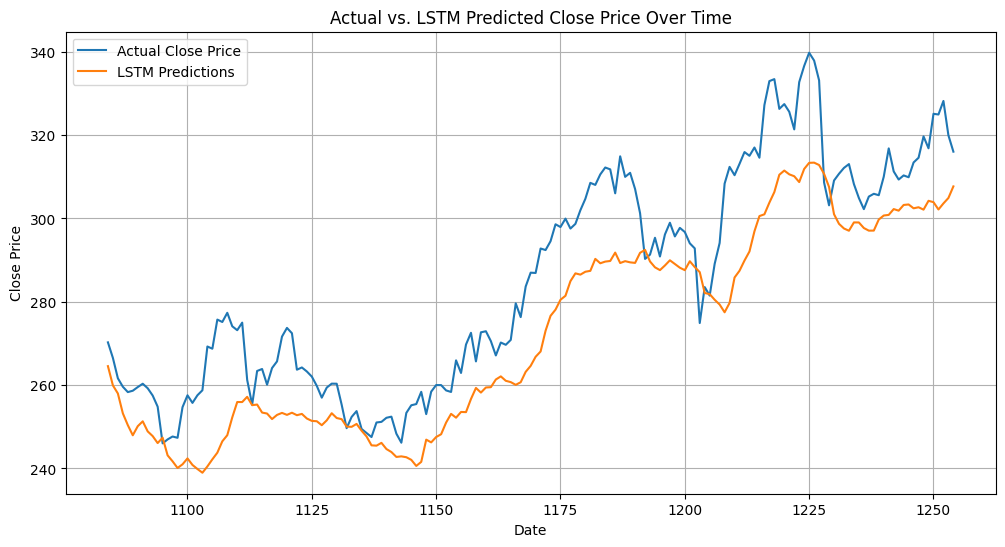

In [ ]:
# Create a date index for the test predictions for plotting
test_dates = df_lstm.index[len(df_lstm) - len(y_test_actual_unscaled):]

plt.figure(figsize=(12, 6))
plt.plot(test_dates, y_test_actual_unscaled, label='Actual Close Price')
plt.plot(test_dates, lstm_predictions, label='LSTM Predictions')
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("Actual vs. LSTM Predicted Close Price Over Time")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Save the trained LSTM model
lstm_model.save('lstm_stock_price_model.keras')
print("LSTM model saved successfully!")

LSTM model saved successfully!


## Summarized lstm findings



## Summary:

### Data Analysis Key Findings

* The LSTM model was trained to predict the 'Close' stock price using various features including time-based variables, moving averages, RSI, VWAP, and lagged close prices.
* The LSTM model achieved a Root Mean Squared Error (RMSE) of 15 on the unscaled test data.
* The R-squared (R2) score for the LSTM model on the unscaled test data is 0.67.
* The LSTM model's R-squared of 0.67 indicates a reasonably good fit (given LSTM predicts long-term non-linear volatalities too) to the data, explaining a significant portion of the variance in the 'Close' price.

